# Doohan sessions to flat and hierarchical LMDPs

This notebook loads a configurable set of sessions from one Doohan maze, reduces every navigation trial to entered maze towers, and scores the resulting independent trajectories under flat and hierarchical goal-conditioned LMDPs.

## 1. Setup paths, select sessions, and build the shared maze

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    raise FileNotFoundError("Run this notebook from the project or notebook directory")

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from andrew_mlmdp import (  # noqa: E402
    DoohanMovementDataset,
    LMDPEnvironment,
    NMFDiscoveryParameters,
    SubgoalBasis,
    discover_soft_subgoals,
    plotting as viz,
    score_flat_movement_dataset,
    score_hierarchical_movement_dataset,
    soft_hierarchy_parameters,
)

GRIDMAZE_DATA = (
    PROJECT_ROOT / "external" / "GridMaze-mFC-ephys-DATA" / "data"
)

SUBJECT_IDS = ["m2"]
MAZE_NAME = "maze_1"
START_DATE = "2022-06-28"
END_DATE = "2022-07-05"

movement_dataset = DoohanMovementDataset.from_data_root(
    GRIDMAZE_DATA,
    subject_ids=SUBJECT_IDS,
    start_date=START_DATE,
    end_date=END_DATE,
    maze_name=MAZE_NAME,
)
sessions = movement_dataset.sessions
definition = movement_dataset.definition
maze = definition.maze
environment = LMDPEnvironment(maze)

print(f"sessions: {len(sessions)}")
print(f"maze: {movement_dataset.maze_name}")
print(f"tower grid shape: {maze.shape}")
print(f"physical states: {len(maze.free_cells)}")

sessions: 8
maze: maze_1
tower grid shape: (7, 7)
physical states: 49


## 2. Inspect the assembled navigation trials

The Doohan movement dataset owns session discovery and trial extraction. It removes missing positions and bridge labels, collapses consecutive towers, converts labels to coordinates, truncates each trajectory at its first goal entry, and retains malformed sessions or trials as explicit exclusions.

In [9]:
movement_trials = list(movement_dataset.trials)
exclusion_rows = [
    {
        "session": exclusion.session_id,
        "trial": exclusion.trial_id,
        "goal": exclusion.goal_label,
        "transitions": 0,
        "flat_log_likelihood": float("nan"),
        "hierarchical_log_likelihood": float("nan"),
        "status": "excluded",
        "exclusion_reason": f"data: {exclusion.reason}",
    }
    for exclusion in movement_dataset.exclusions
]

print(f"valid trials: {len(movement_trials)}")
print(f"data exclusions: {len(exclusion_rows)}")

valid trials: 522
data exclusions: 0


## 3. Inspect the shared maze and one example trial

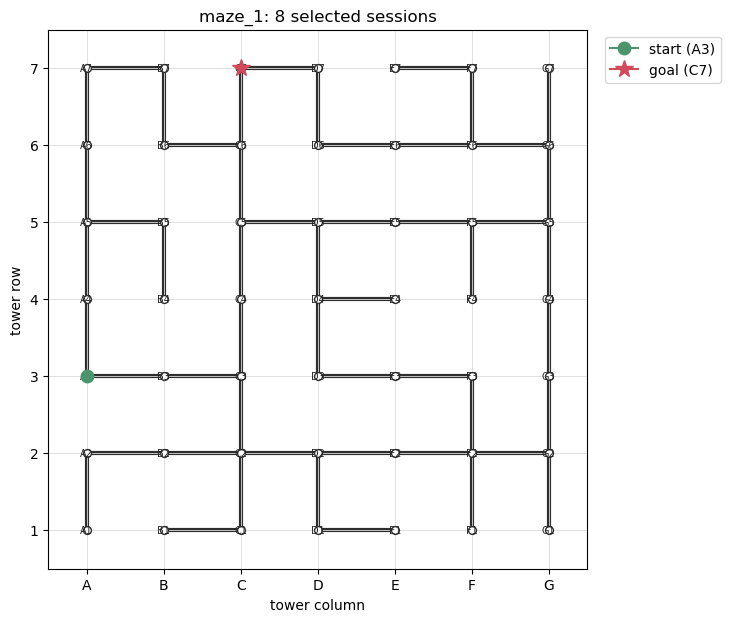

In [10]:
tower_labels = dict(definition.label_by_coordinate)
ax = viz.plot_maze(
    maze,
    labels=tower_labels,
    title=f"{MAZE_NAME}: {len(sessions)} selected sessions",
)
if movement_trials:
    example_trial = movement_trials[0]
    example_start = example_trial.trajectory[0]
    ax.plot(
        example_start[1],
        example_start[0],
        marker="o",
        color="#4c956c",
        markersize=9,
        label=f"start ({definition.label_for(example_start)})",
    )
    ax.plot(
        example_trial.goal[1],
        example_trial.goal[0],
        marker="*",
        color="#d1495b",
        markersize=13,
        label=f"goal ({definition.label_for(example_trial.goal)})",
    )
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.show()

## 4. Build one flat environment and one hierarchy template

The distributed basis is discovered once for the maze, not once per session or trial. Goal-conditioned flat solutions and hierarchy tasks are then created lazily and cached by the dataset scorers.

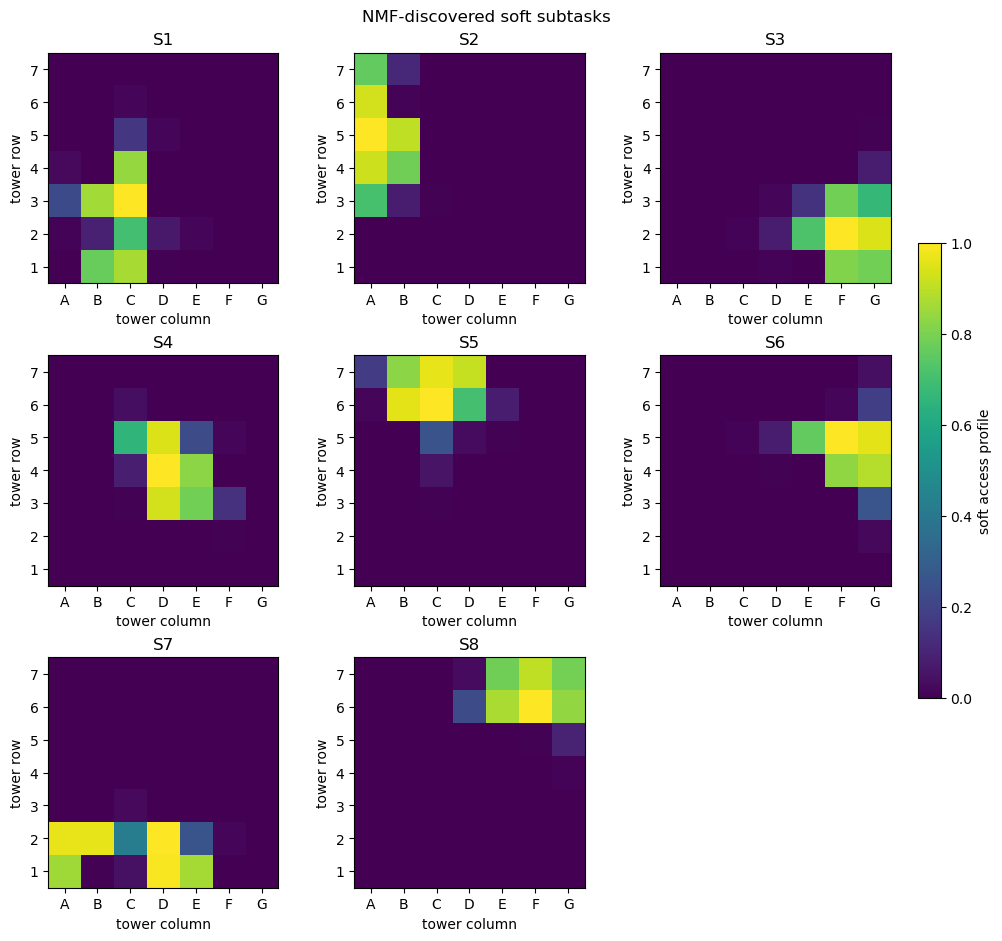

In [11]:
discovery_rank = 8
smoothness_strength = 1.0
soft_discovery = discover_soft_subgoals(
    environment,
    ranks=(discovery_rank,),
    parameters=NMFDiscoveryParameters(
        lambda_smooth=smoothness_strength,
    ),
    seed=0,
).result(discovery_rank)
viz.plot_soft_subtasks(soft_discovery)
plt.show()

soft_basis = SubgoalBasis.from_profiles(
    maze,
    soft_discovery.profiles,
    core_threshold=0.8,
)
hierarchy_template = environment.hierarchy(
    soft_basis,
    parameters=soft_hierarchy_parameters(
        discovery_rank,
        upper_control_cost=0.18,
    ),
    include_goal_component_while_active=False,
)

## 5. Generate one report per model

Each report represents one model result on the selected dataset. The flat and hierarchical reports remain independent; this notebook displays only the hierarchical dataset summary.

In [12]:
flat_report = movement_dataset.report(
    score_flat_movement_dataset(
        environment,
        movement_trials,
    )
)
hierarchical_report = movement_dataset.report(
    score_hierarchical_movement_dataset(
        hierarchy_template,
        movement_trials,
    )
)

display(hierarchical_report.trial_dataframe())
display(hierarchical_report.session_dataframe())


,model,session_id,subject_id,session_date,maze_name,trial_id,goal_label,number_of_transitions,log_likelihood,status,exclusion_reason
0,hierarchical,m2/2022-06-28.maze,m2,2022-06-28,maze_1,1,C7,6,-0.682981,scored,
1,hierarchical,m2/2022-06-28.maze,m2,2022-06-28,maze_1,2,E4,16,-17.619637,scored,
2,hierarchical,m2/2022-06-28.maze,m2,2022-06-28,maze_1,3,A3,18,-31.913079,scored,
3,hierarchical,m2/2022-06-28.maze,m2,2022-06-28,maze_1,4,D3,39,-61.889037,scored,
4,hierarchical,m2/2022-06-28.maze,m2,2022-06-28,maze_1,5,F4,7,-5.487953,scored,
...,...,...,...,...,...,...,...,...,...,...,...
517,hierarchical,m2/2022-07-05.maze,m2,2022-07-05,maze_1,74,F4,9,-8.554700,scored,
518,hierarchical,m2/2022-07-05.maze,m2,2022-07-05,maze_1,75,B6,6,-0.573119,scored,
519,hierarchical,m2/2022-07-05.maze,m2,2022-07-05,maze_1,76,A3,4,-0.575623,scored,
520,hierarchical,m2/2022-07-05.maze,m2,2022-07-05,maze_1,77,G1,21,-29.044109,scored,


,model,session_id,subject_id,session_date,maze_name,scored_trials,excluded_trials,transitions,total_log_likelihood,mean_log_likelihood_per_transition
0,hierarchical,m2/2022-06-28.maze,m2,2022-06-28,maze_1,58,0,797,-1048.300261,-1.315308
1,hierarchical,m2/2022-06-29.maze,m2,2022-06-29,maze_1,60,0,812,-1096.815471,-1.350758
2,hierarchical,m2/2022-06-30.maze,m2,2022-06-30,maze_1,56,0,741,-inf,-inf
3,hierarchical,m2/2022-07-01.maze,m2,2022-07-01,maze_1,66,0,835,-1113.426902,-1.333445
4,hierarchical,m2/2022-07-02.maze,m2,2022-07-02,maze_1,73,0,762,-inf,-inf
5,hierarchical,m2/2022-07-03.maze,m2,2022-07-03,maze_1,59,0,721,-807.316794,-1.119718
6,hierarchical,m2/2022-07-04.maze,m2,2022-07-04,maze_1,72,0,752,-670.935851,-0.892202
7,hierarchical,m2/2022-07-05.maze,m2,2022-07-05,maze_1,78,0,851,-inf,-inf


In [ ]:
example_trial = movement_trials[0] if movement_trials else None
if example_trial is not None:
    example_solution = environment.solve_flat(example_trial.goal)
    goal_state = maze.state_index(example_trial.goal)
    relative_desirability = (
        example_solution.desirability
        / example_solution.desirability[goal_state]
    )
    positive = relative_desirability[relative_desirability > 0.0]
    rows = [coordinate[0] for coordinate in maze.free_cells]
    columns = [coordinate[1] for coordinate in maze.free_cells]

    fig, ax = plt.subplots(figsize=(8, 7))
    viz.plot_maze(maze, show_grid=False, title=None, ax=ax)
    image = ax.scatter(
        columns,
        rows,
        c=relative_desirability,
        cmap="viridis",
        norm=LogNorm(vmin=positive.min(), vmax=1.0),
        s=280,
        edgecolor="white",
        linewidth=0.7,
        zorder=2,
    )
    viz.plot_trajectory_overlay(
        maze,
        example_trial.trajectory,
        goal=example_trial.goal,
        ax=ax,
    )
    ax.legend(loc="upper left", framealpha=0.9)
    ax.set_title(
        "Flat-LMDP and behavior for "
        f"{example_trial.session_id}, trial {example_trial.trial_id}"
    )
    fig.colorbar(image, ax=ax, label="relative desirability (log scale)")
    plt.show()